In [1]:
# Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
# Display settings
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)
pd.set_option('display.float_format', '{:.2f}'.format)
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (14, 6)
plt.rcParams['font.size'] = 12
print("✅ Libraries loaded successfully")

✅ Libraries loaded successfully


In [3]:
!pip install xlrd

In [5]:
import os
data_folder = 'Global GDP and Macroeconomic Indicators Dataset'
files = sorted(os.listdir(data_folder))
# Load all files — skip the 3 metadata rows at the top
datasets = {}
for f in files:
    path = os.path.join(data_folder, f)
    name = f.replace('.xls', '')
    df = pd.read_excel(path, header=3)  # actual header is row 4 (index 3)
    datasets[name] = df
    print(f"\n{'='*60}")
    print(f"📄 {f}")
    print(f"   Shape: {df.shape}")
    print(f"   Columns: {list(df.columns)}")
    print(df.head(3))
print(f"\n\n✅ Loaded {len(datasets)} datasets")


📄 Export.xls
   Shape: (266, 69)
   Columns: ['Country Name', 'Country Code', 'Indicator Name', 'Indicator Code', '1960', '1961', '1962', '1963', '1964', '1965', '1966', '1967', '1968', '1969', '1970', '1971', '1972', '1973', '1974', '1975', '1976', '1977', '1978', '1979', '1980', '1981', '1982', '1983', '1984', '1985', '1986', '1987', '1988', '1989', '1990', '1991', '1992', '1993', '1994', '1995', '1996', '1997', '1998', '1999', '2000', '2001', '2002', '2003', '2004', '2005', '2006', '2007', '2008', '2009', '2010', '2011', '2012', '2013', '2014', '2015', '2016', '2017', '2018', '2019', '2020', '2021', '2022', '2023', '2024']
                  Country Name Country Code  \
0                        Aruba          ABW   
1  Africa Eastern and Southern          AFE   
2                  Afghanistan          AFG   

                             Indicator Name  Indicator Code  1960  1961  1962  \
0  Exports of goods and services (% of GDP)  NE.EXP.GNFS.ZS   NaN   NaN   NaN   
1  Exports of 


📄 Goverment_Expenditure.xls
   Shape: (266, 69)
   Columns: ['Country Name', 'Country Code', 'Indicator Name', 'Indicator Code', '1960', '1961', '1962', '1963', '1964', '1965', '1966', '1967', '1968', '1969', '1970', '1971', '1972', '1973', '1974', '1975', '1976', '1977', '1978', '1979', '1980', '1981', '1982', '1983', '1984', '1985', '1986', '1987', '1988', '1989', '1990', '1991', '1992', '1993', '1994', '1995', '1996', '1997', '1998', '1999', '2000', '2001', '2002', '2003', '2004', '2005', '2006', '2007', '2008', '2009', '2010', '2011', '2012', '2013', '2014', '2015', '2016', '2017', '2018', '2019', '2020', '2021', '2022', '2023', '2024']
                  Country Name Country Code  \
0                        Aruba          ABW   
1  Africa Eastern and Southern          AFE   
2                  Afghanistan          AFG   

                                      Indicator Name     Indicator Code  1960  \
0  Government expenditure on education, total (% ...  SE.XPD.TOTL.GD.ZS   NaN   


📄 Population.xls
   Shape: (266, 69)
   Columns: ['Country Name', 'Country Code', 'Indicator Name', 'Indicator Code', '1960', '1961', '1962', '1963', '1964', '1965', '1966', '1967', '1968', '1969', '1970', '1971', '1972', '1973', '1974', '1975', '1976', '1977', '1978', '1979', '1980', '1981', '1982', '1983', '1984', '1985', '1986', '1987', '1988', '1989', '1990', '1991', '1992', '1993', '1994', '1995', '1996', '1997', '1998', '1999', '2000', '2001', '2002', '2003', '2004', '2005', '2006', '2007', '2008', '2009', '2010', '2011', '2012', '2013', '2014', '2015', '2016', '2017', '2018', '2019', '2020', '2021', '2022', '2023', '2024']
                  Country Name Country Code     Indicator Name Indicator Code  \
0                        Aruba          ABW  Population, total    SP.POP.TOTL   
1  Africa Eastern and Southern          AFE  Population, total    SP.POP.TOTL   
2                  Afghanistan          AFG  Population, total    SP.POP.TOTL   

          1960         1961         

# Melt Each File from Wide to Long Format

In [8]:
# We will process each file: 
# - Drop 'Indicator Name' and 'Indicator Code' (same value for all rows, not useful)
# - Convert from wide format (years as columns) to long format (one row per country per year)

indicator_map = {
    'GDP': 'GDP',                              # Target variable
    'Export': 'Exports',                        # Feature 1
    'Imports': 'Imports',                       # Feature 2
    'FDI inflows': 'FDI_Inflows',              # Feature 3
    'Inflation': 'Inflation',                   # Feature 4
    'Population': 'Population',                 # Feature 5
    'Goverment_Expenditure': 'Govt_Expenditure' # Feature 6
}

melted_frames = []

for file_key, col_name in indicator_map.items():
    df = datasets[file_key].copy()
    
    # Step 1: Drop unnecessary columns
    df.drop(columns=['Indicator Name', 'Indicator Code'], inplace=True)
    
    # Step 2: Separate ID columns from year columns
    year_cols = [c for c in df.columns if c not in ['Country Name', 'Country Code']]
    
    # Step 3: Melt — convert year columns into rows
    df_long = df.melt(
        id_vars=['Country Name', 'Country Code'],   # Keep these as-is
        value_vars=year_cols,                         # These become rows
        var_name='Year',                              # New column for the year
        value_name=col_name                           # New column for the value
    )
    df_long['Year'] = df_long['Year'].astype(int)
    
    melted_frames.append((col_name, df_long))
    print(f" {file_key:30s} → column '{col_name}' | Shape: {df_long.shape}")

print(f"\nTotal files processed: {len(melted_frames)}")
print(f" Target variable: GDP")
print(f" Features: {[name for name, _ in melted_frames if name != 'GDP']}")

 GDP                            → column 'GDP' | Shape: (17290, 4)
 Export                         → column 'Exports' | Shape: (17290, 4)
 Imports                        → column 'Imports' | Shape: (17290, 4)
 FDI inflows                    → column 'FDI_Inflows' | Shape: (17290, 4)
 Inflation                      → column 'Inflation' | Shape: (17290, 4)
 Population                     → column 'Population' | Shape: (17290, 4)
 Goverment_Expenditure          → column 'Govt_Expenditure' | Shape: (17290, 4)

Total files processed: 7
 Target variable: GDP
 Features: ['Exports', 'Imports', 'FDI_Inflows', 'Inflation', 'Population', 'Govt_Expenditure']


# Merge All 7 Files into One Unified DataFrame

In [10]:
# Start with GDP as the base table (our target variable)
base_name, base_df = melted_frames[0]  # GDP
merged_df = base_df.copy()

print(f" Merge keys: 'Country Name' + 'Year'")
print(f" Base table: '{base_name}' → Shape: {merged_df.shape}")
print()

# Merge each feature one by one
for col_name, df_long in melted_frames[1:]:
    # Only take Country Name, Year, and the indicator value (avoid duplicate Country Code)
    temp = df_long[['Country Name', 'Year', col_name]]
    
    # Merge on Country Name + Year
    merged_df = merged_df.merge(temp, on=['Country Name', 'Year'], how='inner')
    print(f"    Merged '{col_name}' → Shape: {merged_df.shape}")

print(f"\n FINAL INTEGRATED DATASET:")
print(f"   Rows: {merged_df.shape[0]}  |  Columns: {merged_df.shape[1]}")
print(f"   Column names: {list(merged_df.columns)}")
print(f"\n   Target:   GDP")
print(f"   Features: Exports, Imports, FDI_Inflows, Inflation, Population, Govt_Expenditure")
print(f"   ID cols:  Country Name, Country Code, Year")

merged_df.head(10)

 Merge keys: 'Country Name' + 'Year'
 Base table: 'GDP' → Shape: (17290, 4)

    Merged 'Exports' → Shape: (17290, 5)
    Merged 'Imports' → Shape: (17290, 6)
    Merged 'FDI_Inflows' → Shape: (17290, 7)
    Merged 'Inflation' → Shape: (17290, 8)
    Merged 'Population' → Shape: (17290, 9)
    Merged 'Govt_Expenditure' → Shape: (17290, 10)

 FINAL INTEGRATED DATASET:
   Rows: 17290  |  Columns: 10
   Column names: ['Country Name', 'Country Code', 'Year', 'GDP', 'Exports', 'Imports', 'FDI_Inflows', 'Inflation', 'Population', 'Govt_Expenditure']

   Target:   GDP
   Features: Exports, Imports, FDI_Inflows, Inflation, Population, Govt_Expenditure
   ID cols:  Country Name, Country Code, Year


,Country Name,Country Code,Year,GDP,Exports,Imports,FDI_Inflows,Inflation,Population,Govt_Expenditure
0,Aruba,ABW,1960,NaN,NaN,NaN,NaN,NaN,54922.00,NaN
1,Africa Eastern and Southern,AFE,1960,24205688712.38,NaN,NaN,NaN,NaN,130075728.00,NaN
2,Afghanistan,AFG,1960,NaN,NaN,NaN,NaN,NaN,9035043.00,NaN
3,Africa Western and Central,AFW,1960,11904805741.68,NaN,NaN,NaN,NaN,97630925.00,NaN
4,Angola,AGO,1960,NaN,NaN,NaN,NaN,NaN,5231654.00,NaN
5,Albania,ALB,1960,NaN,NaN,NaN,NaN,NaN,1608800.00,NaN
6,Andorra,AND,1960,NaN,NaN,NaN,NaN,NaN,9510.00,NaN
7,Arab World,ARB,1960,NaN,NaN,NaN,NaN,NaN,91540853.00,NaN
8,United Arab Emirates,ARE,1960,NaN,NaN,NaN,NaN,NaN,131334.00,NaN
9,Argentina,ARG,1960,15865474315.41,7.60,7.60,NaN,NaN,20386045.00,NaN


# Filter to 2000–2024 + Data Quality Report

In [11]:
# Filter: Keep only years 2000 to 2024
merged_df = merged_df[(merged_df['Year'] >= 2000) & (merged_df['Year'] <= 2024)]
merged_df.reset_index(drop=True, inplace=True)

print(f" Filtered to years 2000–2024")
print(f"   New shape: {merged_df.shape}")
print(f"   Year range: {merged_df['Year'].min()} – {merged_df['Year'].max()}")
print(f"   Countries/Regions: {merged_df['Country Name'].nunique()}")

# Now check missing values
print("\n" + "=" * 65)
print(" DATA QUALITY REPORT (2000–2024)")
print("=" * 65)

missing = merged_df.isnull().sum()
missing_pct = (missing / len(merged_df) * 100).round(2)
missing_report = pd.DataFrame({
    'Missing Count': missing,
    'Missing %': missing_pct,
    'Present Count': len(merged_df) - missing
})
print(missing_report)

# How many complete rows?
complete_rows = merged_df.dropna().shape[0]
print(f"\n Complete rows (zero NaN): {complete_rows} out of {len(merged_df)} ({complete_rows/len(merged_df)*100:.1f}%)")

# How many rows have GDP present?
gdp_present = merged_df['GDP'].notna().sum()
print(f" Rows with GDP present: {gdp_present} out of {len(merged_df)} ({gdp_present/len(merged_df)*100:.1f}%)")

 Filtered to years 2000–2024
   New shape: (6650, 10)
   Year range: 2000 – 2024
   Countries/Regions: 266

 DATA QUALITY REPORT (2000–2024)
                  Missing Count  Missing %  Present Count
Country Name                  0       0.00           6650
Country Code                  0       0.00           6650
Year                          0       0.00           6650
GDP                         217       3.26           6433
Exports                    1141      17.16           5509
Imports                    1114      16.75           5536
FDI_Inflows                 518       7.79           6132
Inflation                   934      14.05           5716
Population                   25       0.38           6625
Govt_Expenditure           2316      34.83           4334

 Complete rows (zero NaN): 3649 out of 6650 (54.9%)
 Rows with GDP present: 6433 out of 6650 (96.7%)


# Handle Missing Values

In [12]:
# Step 1: Drop rows where GDP (our target) is missing
before = len(merged_df)
df_clean = merged_df.dropna(subset=['GDP']).copy()
print(f"Step 1 — Dropped rows with missing GDP:")
print(f"   Before: {before} → After: {len(df_clean)} (dropped {before - len(df_clean)} rows)\n")

Step 1 — Dropped rows with missing GDP:
   Before: 6650 → After: 6433 (dropped 217 rows)



In [13]:
# Step 2: Forward-fill + backward-fill within each country
# This fills gaps using the nearest available year for that same country
feature_cols = ['Exports', 'Imports', 'FDI_Inflows', 'Inflation', 'Population', 'Govt_Expenditure']
df_clean[feature_cols] = df_clean.groupby('Country Name')[feature_cols].transform(
    lambda x: x.ffill().bfill()  # fill forward first, then backward
)
print(f"Step 2 — Forward-fill + backward-fill applied within each country")
# Check what's still missing
still_missing = df_clean[feature_cols].isnull().sum()
print(f"\n   Remaining missing values after filling:")
print(f"   {dict(still_missing)}\n")

Step 2 — Forward-fill + backward-fill applied within each country

   Remaining missing values after filling:
   {'Exports': 638, 'Imports': 613, 'FDI_Inflows': 254, 'Inflation': 464, 'Population': 0, 'Govt_Expenditure': 354}



In [14]:
# Step 3: Drop any rows still having NaN
before2 = len(df_clean)
df_clean.dropna(inplace=True)
df_clean.reset_index(drop=True, inplace=True)
print(f"Step 3 — Dropped remaining rows with NaN:")
print(f"   Before: {before2} → After: {len(df_clean)} (dropped {before2 - len(df_clean)} rows)")
print(f"\n CLEAN DATASET READY:")
print(f"   Shape: {df_clean.shape}")
print(f"   Countries: {df_clean['Country Name'].nunique()}")
print(f"   Year range: {df_clean['Year'].min()} – {df_clean['Year'].max()}")
print(f"   Target: GDP")
print(f"   Features: {feature_cols}")
df_clean.head(10)

Step 3 — Dropped remaining rows with NaN:
   Before: 6433 → After: 5337 (dropped 1096 rows)

 CLEAN DATASET READY:
   Shape: (5337, 10)
   Countries: 215
   Year range: 2000 – 2024
   Target: GDP
   Features: ['Exports', 'Imports', 'FDI_Inflows', 'Inflation', 'Population', 'Govt_Expenditure']


,Country Name,Country Code,Year,GDP,Exports,Imports,FDI_Inflows,Inflation,Population,Govt_Expenditure
0,Aruba,ABW,2000,1873452513.97,74.39,70.69,-6.83,4.04,90588.00,4.71
1,Africa Eastern and Southern,AFE,2000,287041984552.04,25.55,25.81,1.53,8.60,406156661.00,3.61
2,Afghanistan,AFG,2000,3521418059.92,10.42,36.29,0.00,12.69,20130327.00,3.48
3,Angola,AGO,2000,9129594970.15,49.50,41.07,9.62,325.00,16194869.00,2.61
4,Albania,ALB,2000,3584570164.85,19.53,42.08,3.99,0.05,3089027.00,3.43
5,Arab World,ARB,2000,763400003917.07,37.96,29.92,0.50,1.85,286548096.00,4.67
6,United Arab Emirates,ARE,2000,104337372362.15,49.16,40.71,-0.49,12.25,3493575.00,3.86
7,Argentina,ARG,2000,284203750000.00,10.99,11.64,3.67,34.28,37213984.00,4.58
8,Armenia,ARM,2000,1911563668.85,22.16,50.07,5.45,-0.79,3221100.00,2.77
9,Antigua and Barbuda,ATG,2000,901003703.70,74.51,67.04,10.71,0.77,74912.00,3.08


# Save the Integrated & Cleaned Dataset

In [15]:
df_clean.to_csv('Integrated_GDP_Dataset.csv', index=False)
print(f" Saved: Integrated_GDP_Dataset.csv")
print(f"   Shape: {df_clean.shape}")
print(f"   Size: {round(os.path.getsize('Integrated_GDP_Dataset.csv') / 1024, 1)} KB")

 Saved: Integrated_GDP_Dataset.csv
   Shape: (5337, 10)
   Size: 744.2 KB


# EDA: Descriptive Statistics

In [17]:
print(" DESCRIPTIVE STATISTICS")
print("=" * 100)
print(f"Target variable: GDP (in current US$)")
print(f"Features: Exports, Imports, FDI_Inflows, Inflation, Population, Govt_Expenditure")
print()
df_clean.describe().round(2)

 DESCRIPTIVE STATISTICS
Target variable: GDP (in current US$)
Features: Exports, Imports, FDI_Inflows, Inflation, Population, Govt_Expenditure



,Year,GDP,Exports,Imports,FDI_Inflows,Inflation,Population,Govt_Expenditure
count,5337.00,5337.00,5337.00,5337.00,5337.00,5337.00,5337.00,5337.00
mean,2011.98,2640888166528.06,40.67,44.70,6.41,6.74,352238725.94,4.28
std,7.19,8841727355258.43,29.68,27.50,41.14,20.12,992797749.99,1.79
min,2000.00,21017423.61,0.72,1.13,-391.56,-16.86,10009.00,0.00
25%,2006.00,11697918243.00,23.08,27.12,1.25,1.93,3728004.00,3.16
50%,2012.00,68507731353.91,31.83,35.74,2.58,3.66,14013808.00,4.05
75%,2018.00,733628247119.08,50.33,55.79,4.59,6.57,100099099.00,5.11
max,2024.00,110982661180013.44,228.99,221.01,1709.83,557.20,8141808945.00,16.39


1- GDP ranges from $21M to $111 trillion — huge range (includes small islands + world aggregates)
2- FDI_Inflows has extreme values (-391% to 1709%) — some outliers
3- Inflation max is 557% — hyperinflation cases
4- Population max is 8.1 billion — that's the "World" aggregate row

# EDA: GDP Trends of Top 10 Economies

In [18]:
# Find the top 10 countries by GDP in the latest year
latest_year = df_clean['Year'].max()
top10 = df_clean[df_clean['Year'] == latest_year].nlargest(10, 'GDP')['Country Name'].tolist()
print(f" Top 10 economies by GDP in {latest_year}:")
for i, c in enumerate(top10, 1):
    gdp_val = df_clean[(df_clean['Country Name'] == c) & (df_clean['Year'] == latest_year)]['GDP'].values[0]
    print(f"   {i:2d}. {c:30s} → ${gdp_val/1e12:.2f} Trillion")

 Top 10 economies by GDP in 2024:
    1. World                          → $110.98 Trillion
    2. High income                    → $71.32 Trillion
    3. OECD members                   → $67.50 Trillion
    4. Post-demographic dividend      → $62.79 Trillion
    5. IDA & IBRD total               → $43.82 Trillion
    6. IBRD only                      → $40.93 Trillion
    7. Low & middle income            → $39.40 Trillion
    8. Middle income                  → $38.93 Trillion
    9. East Asia & Pacific            → $32.02 Trillion
   10. North America                  → $31.00 Trillion


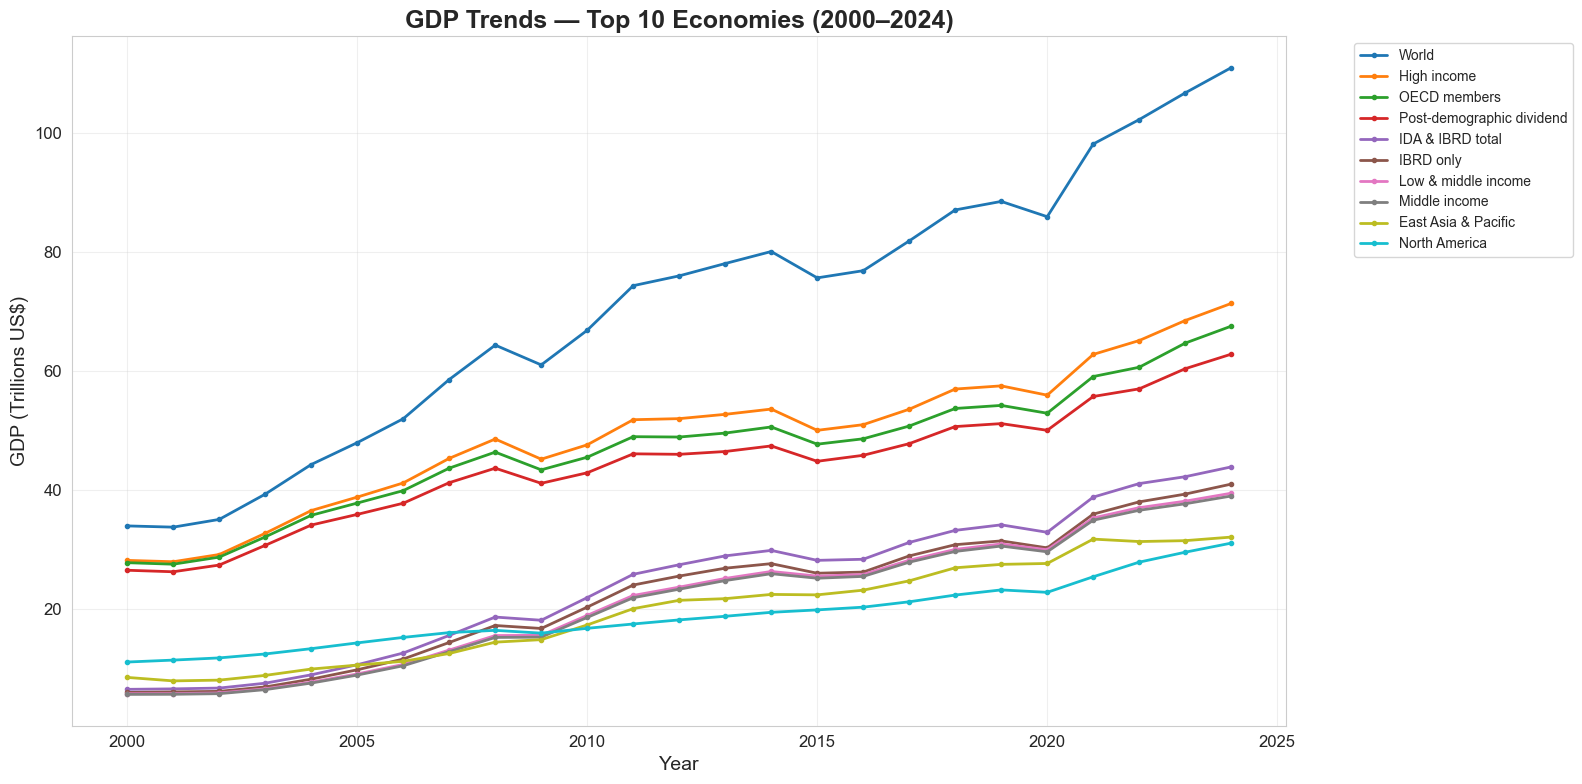

In [19]:
# Plot
fig, ax = plt.subplots(figsize=(16, 8))
for c in top10:
    subset = df_clean[df_clean['Country Name'] == c]
    ax.plot(subset['Year'], subset['GDP'] / 1e12, label=c, linewidth=2, marker='o', markersize=3)
ax.set_title('GDP Trends — Top 10 Economies (2000–2024)', fontsize=18, fontweight='bold')
ax.set_xlabel('Year', fontsize=14)
ax.set_ylabel('GDP (Trillions US$)', fontsize=14)
ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=10)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

Notice the top 10 are all aggregate regions (World, High Income, OECD...) — not actual countries! The dataset includes World Bank group totals. Let's redo this with actual countries only, and also remove those aggregates for our ML later (since "World" GDP = sum of all countries = data leakage).

# Remove Aggregate Regions + Plot Top 10 Countries

In [20]:
# These are World Bank aggregate/group codes — not real countries
# We identify them: they usually have long names like "World", "High income", etc.
# Quick way: real countries have a population < 2 billion (no single country exceeds that)
aggregates = df_clean[df_clean['Population'] > 2e9]['Country Name'].unique().tolist()
# Also manually add common aggregates that may slip through
known_aggregates = [
    'World', 'High income', 'Low income', 'Middle income', 'Upper middle income',
    'Lower middle income', 'Low & middle income', 'OECD members',
    'IDA & IBRD total', 'IBRD only', 'IDA total', 'IDA only', 'IDA blend',
    'East Asia & Pacific', 'Europe & Central Asia', 'Latin America & Caribbean',
    'Middle East & North Africa', 'North America', 'South Asia', 'Sub-Saharan Africa',
    'Euro area', 'European Union', 'Arab World', 'Central Europe and the Baltics',
    'Post-demographic dividend', 'Pre-demographic dividend', 'Late-demographic dividend',
    'Early-demographic dividend', 'Fragile and conflict affected situations',
    'Heavily indebted poor countries (HIPC)', 'Least developed countries: UN classification',
    'Small states', 'Other small states', 'Pacific island small states',
    'Caribbean small states', 'East Asia & Pacific (excluding high income)',
    'Europe & Central Asia (excluding high income)', 'Africa Eastern and Southern',
    'Africa Western and Central', 'Latin America & Caribbean (excluding high income)',
    'Middle East & North Africa (excluding high income)', 'South Asia (IDA & IBRD)',
    'Sub-Saharan Africa (excluding high income)', 'Sub-Saharan Africa (IDA & IBRD countries)',
    'Not classified', 'North America'
]
all_aggregates = list(set(aggregates + known_aggregates))

In [21]:
before = len(df_clean)
df_clean = df_clean[~df_clean['Country Name'].isin(all_aggregates)].copy()
df_clean.reset_index(drop=True, inplace=True)
print(f" Removed aggregate regions:")
print(f"   Before: {before} rows → After: {len(df_clean)} rows")
print(f"   Countries remaining: {df_clean['Country Name'].nunique()}")

 Removed aggregate regions:
   Before: 5337 rows → After: 4362 rows
   Countries remaining: 176


In [22]:
# Now plot TOP 10 actual countries
latest_year = df_clean['Year'].max()
top10 = df_clean[df_clean['Year'] == latest_year].nlargest(10, 'GDP')['Country Name'].tolist()
print(f"\n Top 10 countries by GDP in {latest_year}:")
for i, c in enumerate(top10, 1):
    gdp_val = df_clean[(df_clean['Country Name'] == c) & (df_clean['Year'] == latest_year)]['GDP'].values[0]
    print(f"   {i:2d}. {c:30s} → ${gdp_val/1e12:.2f} Trillion")


 Top 10 countries by GDP in 2024:
    1. United States                  → $28.75 Trillion
    2. China                          → $18.74 Trillion
    3. Latin America & the Caribbean (IDA & IBRD countries) → $6.78 Trillion
    4. Europe & Central Asia (IDA & IBRD countries) → $6.13 Trillion
    5. Middle East, North Africa, Afghanistan & Pakistan → $5.09 Trillion
    6. Germany                        → $4.69 Trillion
    7. Japan                          → $4.03 Trillion
    8. India                          → $3.91 Trillion
    9. United Kingdom                 → $3.69 Trillion
   10. France                         → $3.16 Trillion


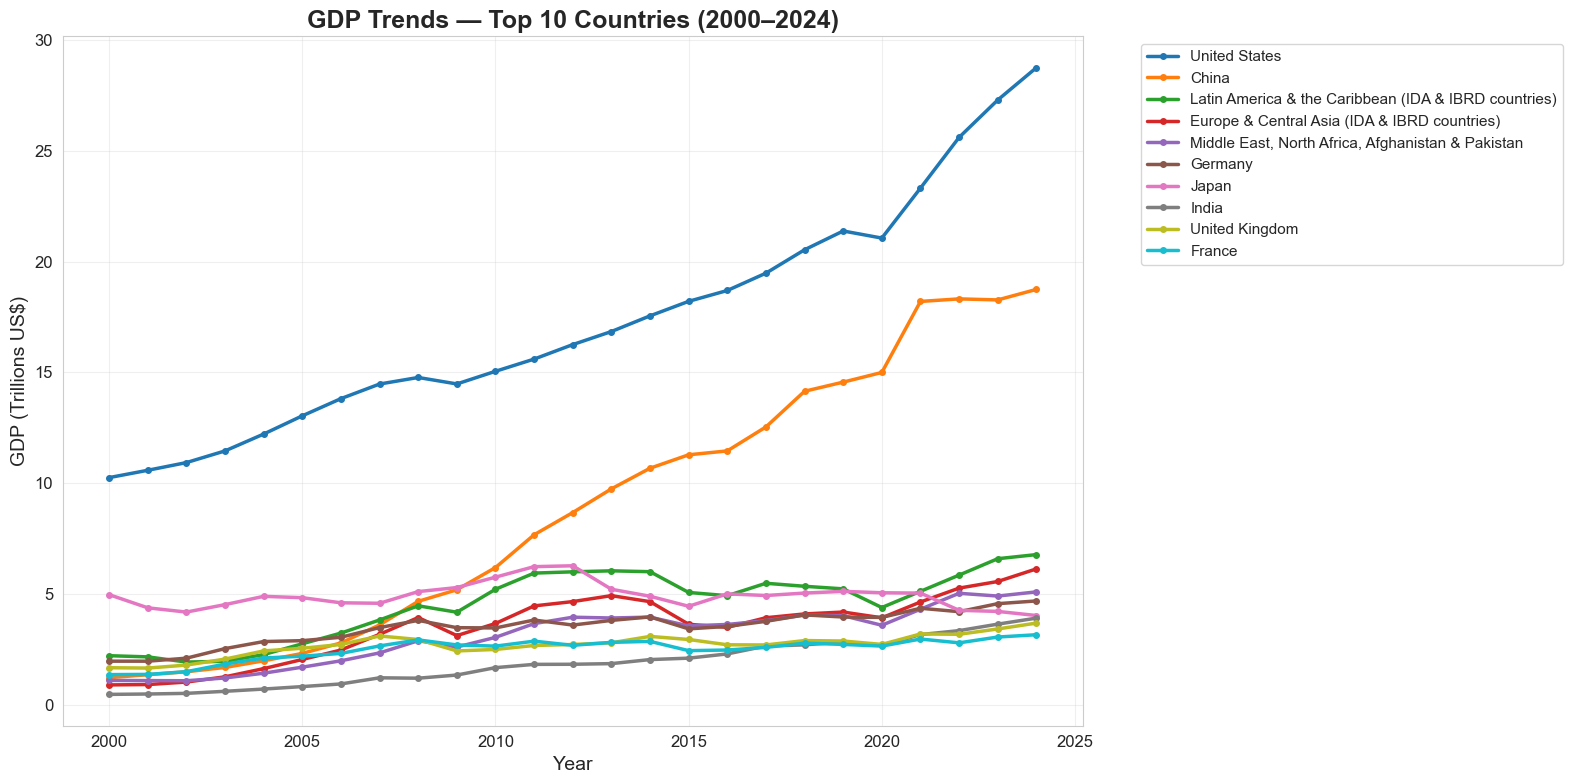

In [23]:
fig, ax = plt.subplots(figsize=(16, 8))
for c in top10:
    subset = df_clean[df_clean['Country Name'] == c]
    ax.plot(subset['Year'], subset['GDP'] / 1e12, label=c, linewidth=2.5, marker='o', markersize=4)
ax.set_title('GDP Trends — Top 10 Countries (2000–2024)', fontsize=18, fontweight='bold')
ax.set_xlabel('Year', fontsize=14)
ax.set_ylabel('GDP (Trillions US$)', fontsize=14)
ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=11)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Remove Remaining Aggregates

In [25]:
# A few more aggregate groups slipped through — let's catch them
# Any name containing keywords like "IDA", "IBRD", "income", region-like patterns
import re
def is_aggregate(name):
    patterns = ['IDA', 'IBRD', 'income', 'dividend', 'classified', 'small states',
                'fragile', 'HIPC', 'least developed', 'heavily indebted',
                'Middle East, North Africa, Afghanistan']
    return any(p.lower() in name.lower() for p in patterns)
agg_names = [name for name in df_clean['Country Name'].unique() if is_aggregate(name)]
if agg_names:
    print(f" Found {len(agg_names)} more aggregates to remove:")
    for a in sorted(agg_names):
        print(f"    {a}")
    
    df_clean = df_clean[~df_clean['Country Name'].isin(agg_names)].copy()
    df_clean.reset_index(drop=True, inplace=True)
print(f"\n Final clean dataset:")
print(f"   Shape: {df_clean.shape}")
print(f"   Countries: {df_clean['Country Name'].nunique()}")


 Final clean dataset:
   Shape: (4237, 10)
   Countries: 171


In [26]:
# Verify top 10 now
latest_year = df_clean['Year'].max()
top10 = df_clean[df_clean['Year'] == latest_year].nlargest(10, 'GDP')['Country Name'].tolist()
print(f"\n Top 10 countries by GDP in {latest_year}:")
for i, c in enumerate(top10, 1):
    gdp_val = df_clean[(df_clean['Country Name'] == c) & (df_clean['Year'] == latest_year)]['GDP'].values[0]
    print(f"   {i:2d}. {c:30s} → ${gdp_val/1e12:.2f} Trillion")


 Top 10 countries by GDP in 2024:
    1. United States                  → $28.75 Trillion
    2. China                          → $18.74 Trillion
    3. Germany                        → $4.69 Trillion
    4. Japan                          → $4.03 Trillion
    5. India                          → $3.91 Trillion
    6. United Kingdom                 → $3.69 Trillion
    7. France                         → $3.16 Trillion
    8. Italy                          → $2.38 Trillion
    9. Canada                         → $2.24 Trillion
   10. Brazil                         → $2.19 Trillion


# EDA: Correlation Heatmap

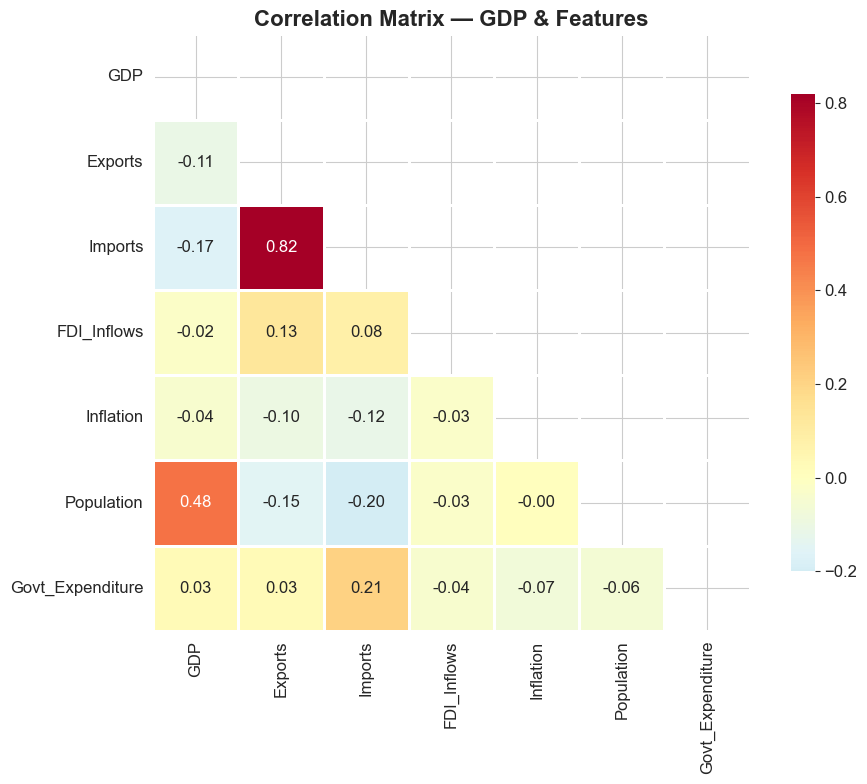


 Correlation with GDP:
   Population           → +0.48 (Moderate)
   Govt_Expenditure     → +0.03 (Weak)
   FDI_Inflows          → -0.02 (Weak)
   Inflation            → -0.04 (Weak)
   Exports              → -0.11 (Weak)
   Imports              → -0.17 (Weak)


In [27]:
feature_cols = ['Exports', 'Imports', 'FDI_Inflows', 'Inflation', 'Population', 'Govt_Expenditure']
corr_cols = ['GDP'] + feature_cols
corr_matrix = df_clean[corr_cols].corr().round(2)
fig, ax = plt.subplots(figsize=(10, 8))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f', cmap='RdYlBu_r',
            center=0, square=True, linewidths=1, ax=ax,
            cbar_kws={'shrink': 0.8}, annot_kws={'size': 12})
ax.set_title('Correlation Matrix — GDP & Features', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()
# Print GDP correlations specifically
print("\n Correlation with GDP:")
gdp_corr = corr_matrix['GDP'].drop('GDP').sort_values(ascending=False)
for feat, val in gdp_corr.items():
    strength = "Strong" if abs(val) > 0.5 else "Moderate" if abs(val) > 0.3 else "Weak"
    print(f"   {feat:20s} → {val:+.2f} ({strength})")

# EDA: Distribution of Each Feature

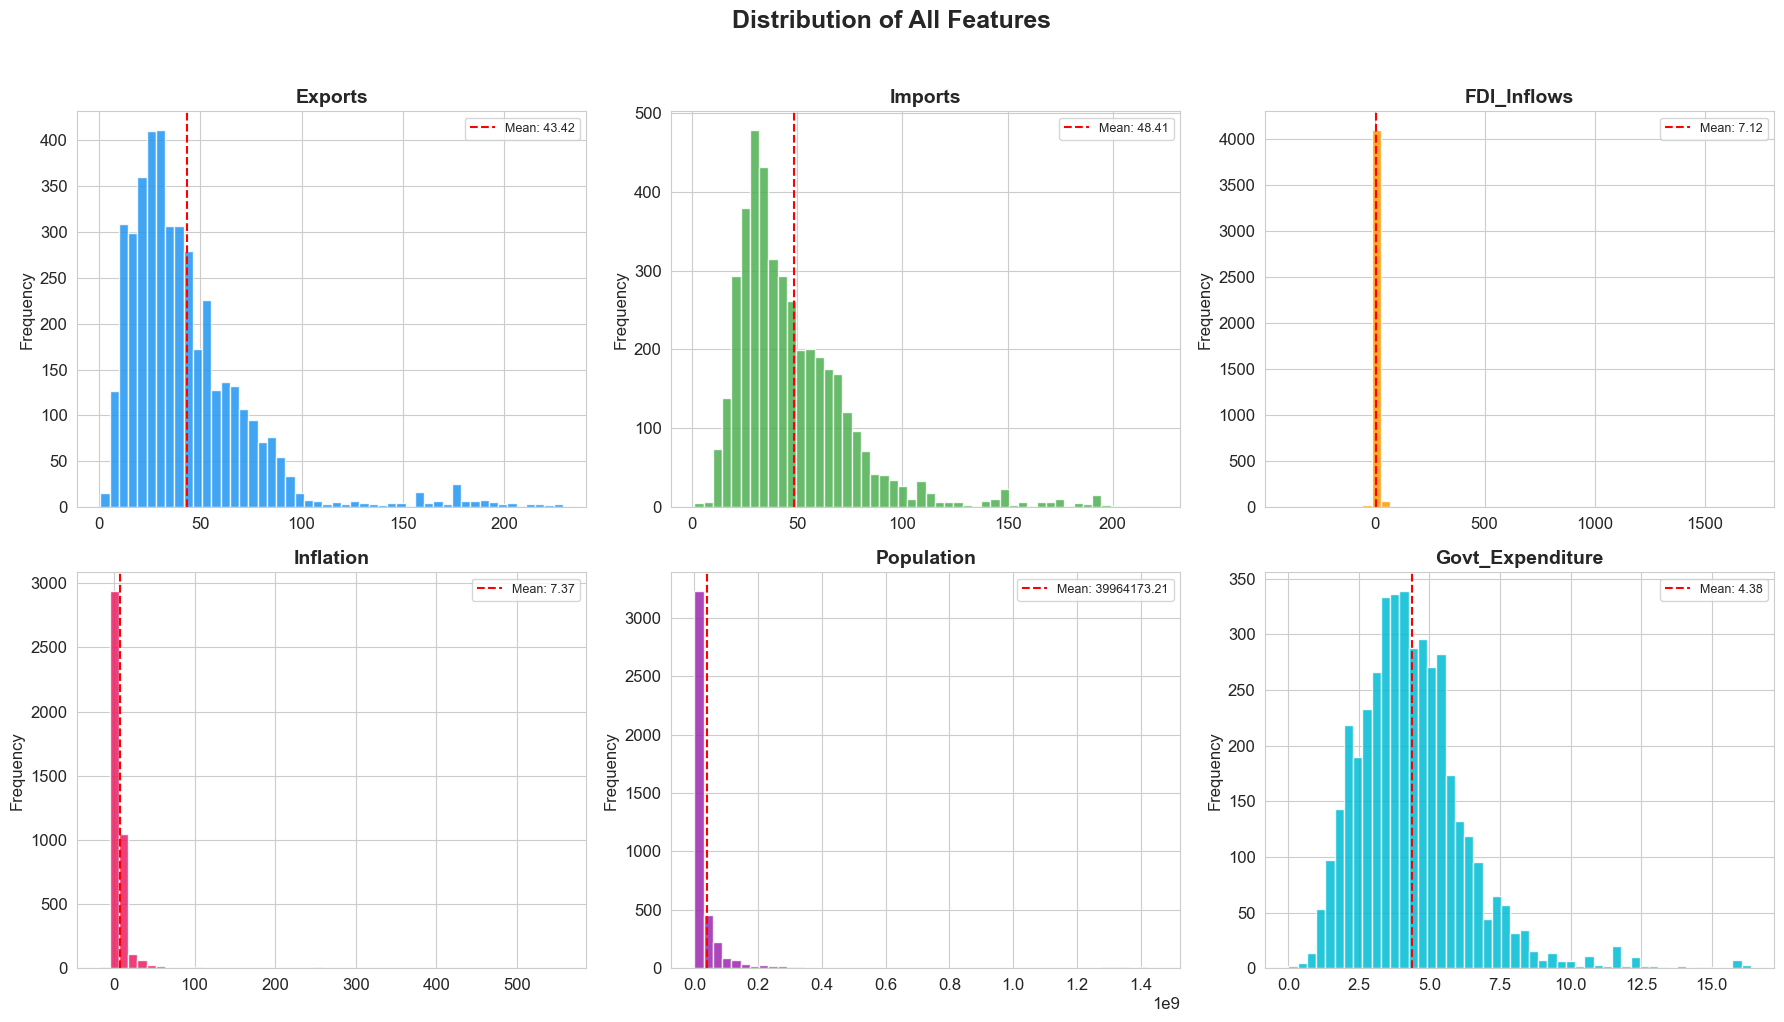

In [28]:
#What this does: Shows histograms — how each feature's values are spread. Helps spot outliers and skewness.
feature_cols = ['Exports', 'Imports', 'FDI_Inflows', 'Inflation', 'Population', 'Govt_Expenditure']

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

colors = ['#2196F3', '#4CAF50', '#FF9800', '#E91E63', '#9C27B0', '#00BCD4']

for i, col in enumerate(feature_cols):
    axes[i].hist(df_clean[col].dropna(), bins=50, color=colors[i], edgecolor='white', alpha=0.85)
    axes[i].set_title(col, fontsize=14, fontweight='bold')
    axes[i].set_ylabel('Frequency')
    # Add mean line
    mean_val = df_clean[col].mean()
    axes[i].axvline(mean_val, color='red', linestyle='--', linewidth=1.5, label=f'Mean: {mean_val:.2f}')
    axes[i].legend(fontsize=9)

plt.suptitle('Distribution of All Features', fontsize=18, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

# EDA: Scatter Plots — Each Feature vs GDP

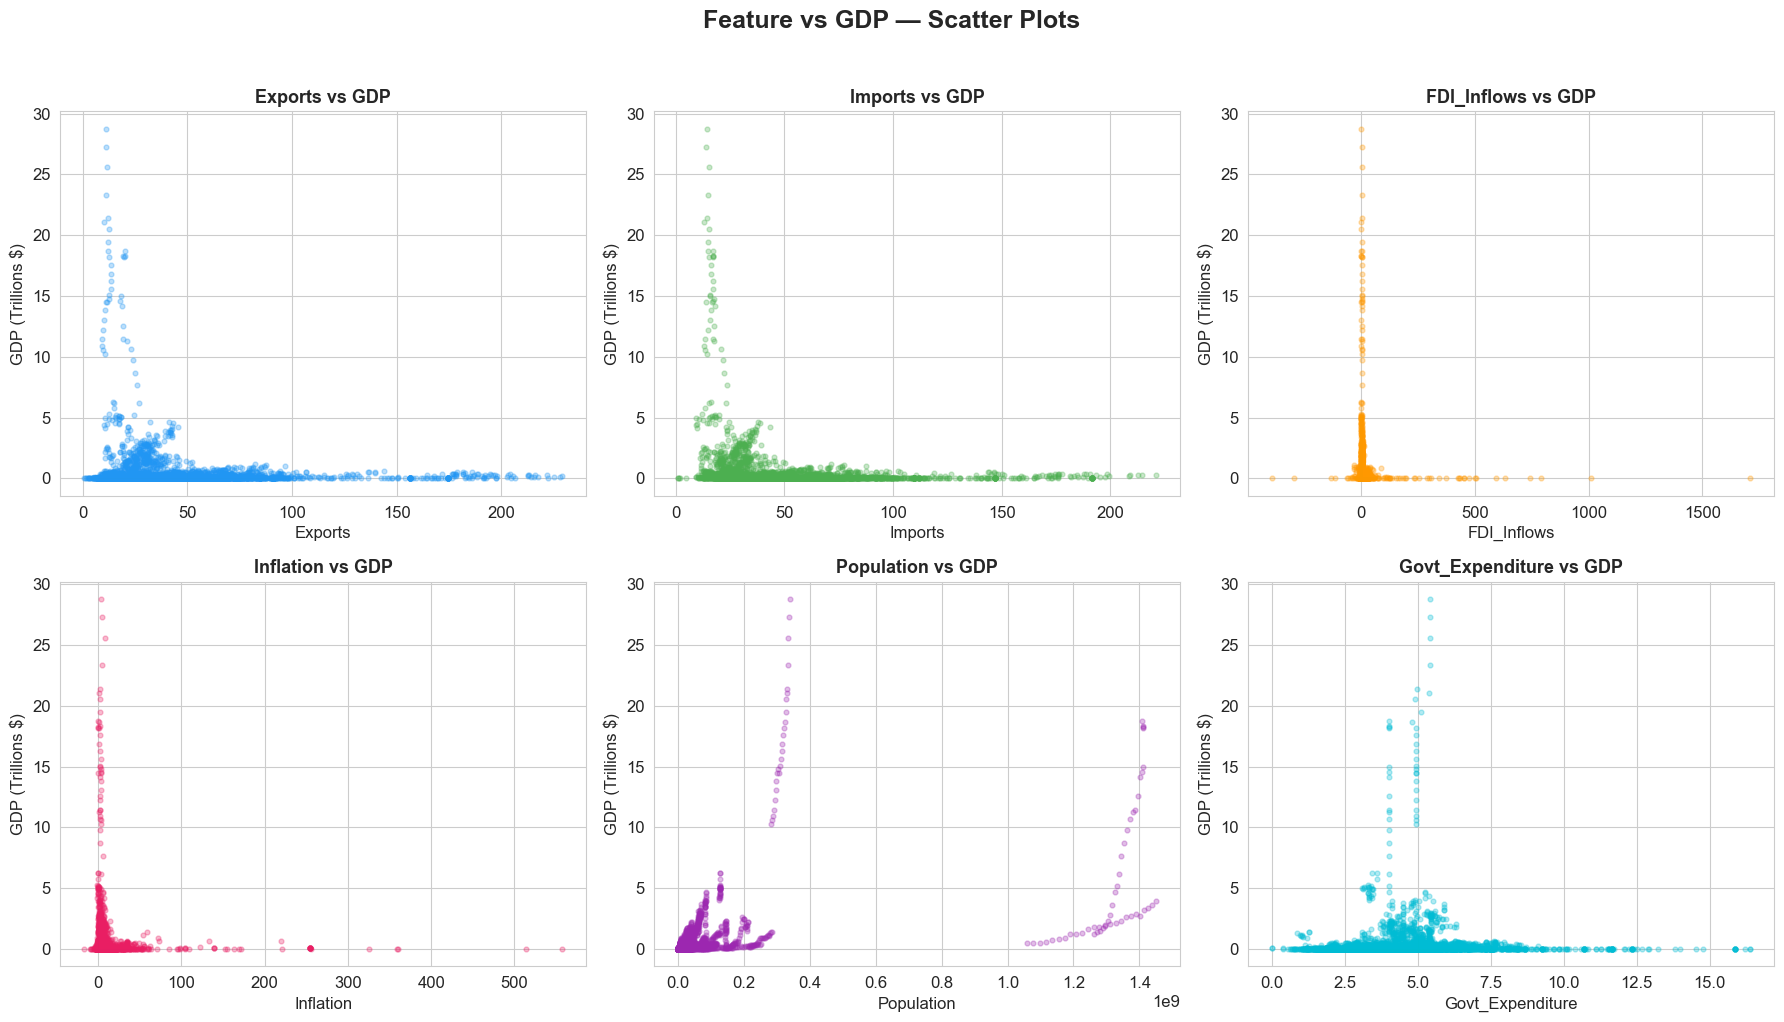

In [29]:
#What this does: Shows the relationship between each feature and GDP visually. Each dot = one country in one year.
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()
colors = ['#2196F3', '#4CAF50', '#FF9800', '#E91E63', '#9C27B0', '#00BCD4']
for i, col in enumerate(feature_cols):
    axes[i].scatter(df_clean[col], df_clean['GDP'] / 1e12, alpha=0.3, s=12, color=colors[i])
    axes[i].set_xlabel(col, fontsize=12)
    axes[i].set_ylabel('GDP (Trillions $)', fontsize=12)
    axes[i].set_title(f'{col} vs GDP', fontsize=13, fontweight='bold')
plt.suptitle('Feature vs GDP — Scatter Plots', fontsize=18, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

# Feature Selection using Random Forest

In [30]:
from sklearn.ensemble import RandomForestRegressor
feature_cols = ['Exports', 'Imports', 'FDI_Inflows', 'Inflation', 'Population', 'Govt_Expenditure']
X = df_clean[feature_cols]
y = df_clean['GDP']

In [31]:
# Fit a Random Forest just for feature importance ranking
rf_temp = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
rf_temp.fit(X, y)

,n_estimators,100
,criterion,'squared_error'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [32]:
# Get feature importances
importance = pd.DataFrame({
    'Feature': feature_cols,
    'Importance': rf_temp.feature_importances_
}).sort_values('Importance', ascending=True)

Text(0.5, 0, 'Importance Score')

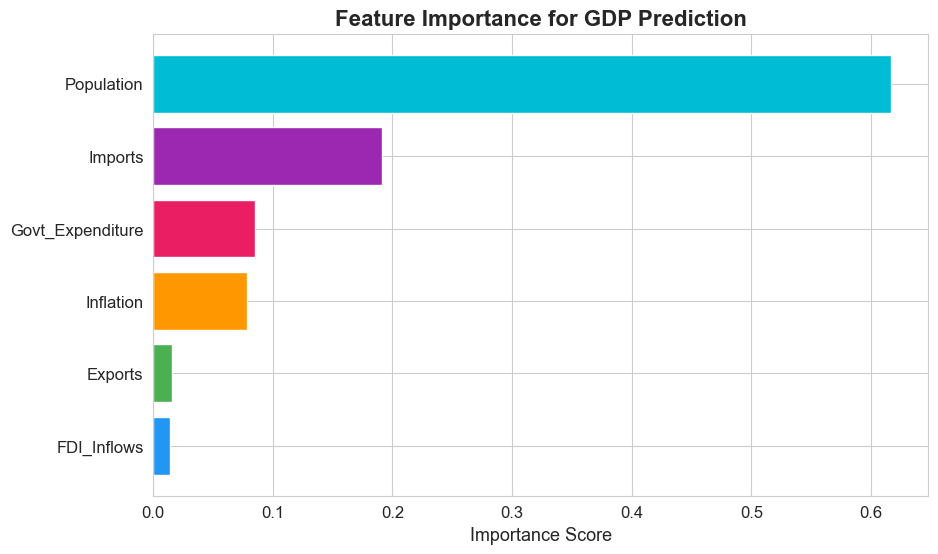

In [33]:
# Plot
fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.barh(importance['Feature'], importance['Importance'], 
               color=['#2196F3', '#4CAF50', '#FF9800', '#E91E63', '#9C27B0', '#00BCD4'])
ax.set_title('Feature Importance for GDP Prediction', fontsize=16, fontweight='bold')
ax.set_xlabel('Importance Score', fontsize=13)

In [34]:
# Add value labels on bars
for bar, val in zip(bars, importance['Importance']):
    ax.text(bar.get_width() + 0.005, bar.get_y() + bar.get_height()/2, 
            f'{val:.3f}', va='center', fontsize=11)
plt.tight_layout()
plt.show()
print("\n Feature Importance Ranking (highest = most important):")
for _, row in importance.sort_values('Importance', ascending=False).iterrows():
    print(f"   {row['Feature']:20s} → {row['Importance']:.4f}")
print("\n We will use ALL 6 features for modeling (let the model decide what's useful)")

<Figure size 1400x600 with 0 Axes>


 Feature Importance Ranking (highest = most important):
   Population           → 0.6170
   Imports              → 0.1909
   Govt_Expenditure     → 0.0848
   Inflation            → 0.0780
   Exports              → 0.0156
   FDI_Inflows          → 0.0137

 We will use ALL 6 features for modeling (let the model decide what's useful)


# Train/Test Split

In [35]:
from sklearn.model_selection import train_test_split
feature_cols = ['Exports', 'Imports', 'FDI_Inflows', 'Inflation', 'Population', 'Govt_Expenditure']
X = df_clean[feature_cols]   # Features (what we use to predict)
y = df_clean['GDP']           # Target (what we want to predict)

In [36]:
# 80% train, 20% test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [37]:
print(" TRAIN/TEST SPLIT")
print("=" * 45)
print(f"   Total samples:    {len(X)}")
print(f"   Training samples: {len(X_train)} (80%)")
print(f"   Testing samples:  {len(X_test)} (20%)")
print(f"\n   Features used ({len(feature_cols)}):")
for f in feature_cols:
    print(f"      • {f}")
print(f"\n   Target: GDP (current US$)")

 TRAIN/TEST SPLIT
   Total samples:    4237
   Training samples: 3389 (80%)
   Testing samples:  848 (20%)

   Features used (6):
      • Exports
      • Imports
      • FDI_Inflows
      • Inflation
      • Population
      • Govt_Expenditure

   Target: GDP (current US$)


# Model 1: Decision Tree Regressor

In [38]:
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
# Train the model
dt_model = DecisionTreeRegressor(max_depth=10, min_samples_split=10, random_state=42)
dt_model.fit(X_train, y_train)

,criterion,'squared_error'
,splitter,'best'
,max_depth,10
,min_samples_split,10
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,ccp_alpha,0.0


In [39]:
# Predict on test set
y_pred_dt = dt_model.predict(X_test)

In [40]:
# Evaluate
dt_mae = mean_absolute_error(y_test, y_pred_dt)
dt_rmse = np.sqrt(mean_squared_error(y_test, y_pred_dt))
dt_r2 = r2_score(y_test, y_pred_dt)

In [41]:
print(" MODEL 1: Decision Tree Regressor")
print("=" * 45)
print(f"   MAE  (Mean Absolute Error):  ${dt_mae/1e9:.2f} Billion")
print(f"   RMSE (Root Mean Sq Error):   ${dt_rmse/1e9:.2f} Billion")
print(f"   R² Score:                    {dt_r2:.4f}")
print(f"\n    R² = {dt_r2:.4f} means the model explains {dt_r2*100:.1f}% of GDP variance")

 MODEL 1: Decision Tree Regressor
   MAE  (Mean Absolute Error):  $123.12 Billion
   RMSE (Root Mean Sq Error):   $598.42 Billion
   R² Score:                    0.8591

    R² = 0.8591 means the model explains 85.9% of GDP variance


# Model 2: Random Forest Regressor

In [42]:
from sklearn.ensemble import RandomForestRegressor
# Train the model
rf_model = RandomForestRegressor(
    n_estimators=200,       # 200 trees
    max_depth=15,           # max depth per tree
    min_samples_split=5,    # min samples to split a node
    random_state=42,
    n_jobs=-1               # use all CPU cores
)
rf_model.fit(X_train, y_train)

,n_estimators,200
,criterion,'squared_error'
,max_depth,15
,min_samples_split,5
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [43]:
# Predict on test set
y_pred_rf = rf_model.predict(X_test)
# Evaluate
rf_mae = mean_absolute_error(y_test, y_pred_rf)
rf_rmse = np.sqrt(mean_squared_error(y_test, y_pred_rf))
rf_r2 = r2_score(y_test, y_pred_rf)

In [44]:
print(" MODEL 2: Random Forest Regressor")
print("=" * 45)
print(f"   MAE  (Mean Absolute Error):  ${rf_mae/1e9:.2f} Billion")
print(f"   RMSE (Root Mean Sq Error):   ${rf_rmse/1e9:.2f} Billion")
print(f"   R² Score:                    {rf_r2:.4f}")
print(f"\n    R² = {rf_r2:.4f} means the model explains {rf_r2*100:.1f}% of GDP variance")

 MODEL 2: Random Forest Regressor
   MAE  (Mean Absolute Error):  $114.73 Billion
   RMSE (Root Mean Sq Error):   $448.09 Billion
   R² Score:                    0.9210

    R² = 0.9210 means the model explains 92.1% of GDP variance


# Model Comparison

In [45]:
# Comparison table
print(" MODEL COMPARISON")
print("=" * 60)
print(f"{'Metric':<30} {'Decision Tree':>15} {'Random Forest':>15}")
print("-" * 60)
print(f"{'MAE (Billion $)':<30} {dt_mae/1e9:>15.2f} {rf_mae/1e9:>15.2f}")
print(f"{'RMSE (Billion $)':<30} {dt_rmse/1e9:>15.2f} {rf_rmse/1e9:>15.2f}")
print(f"{'R² Score':<30} {dt_r2:>15.4f} {rf_r2:>15.4f}")
print("-" * 60)
best = "Random Forest " if rf_r2 > dt_r2 else "Decision Tree "
print(f"{' Winner:':<30} {best:>15}")

 MODEL COMPARISON
Metric                           Decision Tree   Random Forest
------------------------------------------------------------
MAE (Billion $)                         123.12          114.73
RMSE (Billion $)                        598.42          448.09
R² Score                                0.8591          0.9210
------------------------------------------------------------
 Winner:                        Random Forest 


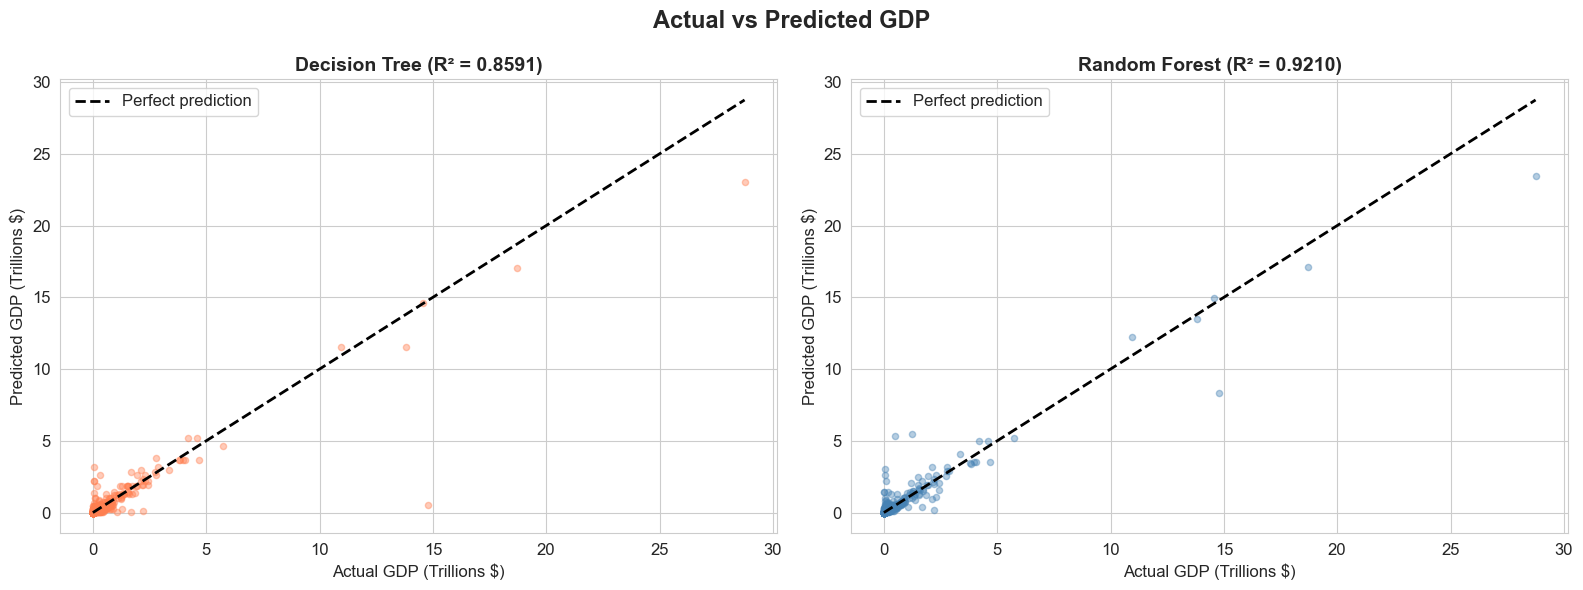


💡 Points closer to the dashed line = better predictions


In [48]:
# Actual vs Predicted plots
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
# Decision Tree
axes[0].scatter(y_test / 1e12, y_pred_dt / 1e12, alpha=0.4, s=20, color='coral')
axes[0].plot([0, y_test.max()/1e12], [0, y_test.max()/1e12], 'k--', lw=2, label='Perfect prediction')
axes[0].set_title(f'Decision Tree (R² = {dt_r2:.4f})', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Actual GDP (Trillions $)', fontsize=12)
axes[0].set_ylabel('Predicted GDP (Trillions $)', fontsize=12)
axes[0].legend()
# Random Forest
axes[1].scatter(y_test / 1e12, y_pred_rf / 1e12, alpha=0.4, s=20, color='steelblue')
axes[1].plot([0, y_test.max()/1e12], [0, y_test.max()/1e12], 'k--', lw=2, label='Perfect prediction')
axes[1].set_title(f'Random Forest (R² = {rf_r2:.4f})', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Actual GDP (Trillions $)', fontsize=12)
axes[1].set_ylabel('Predicted GDP (Trillions $)', fontsize=12)
axes[1].legend()
plt.suptitle('Actual vs Predicted GDP', fontsize=17, fontweight='bold')
plt.tight_layout()
plt.show()
print("\n Points closer to the dashed line = better predictions")

# Residual Analysis

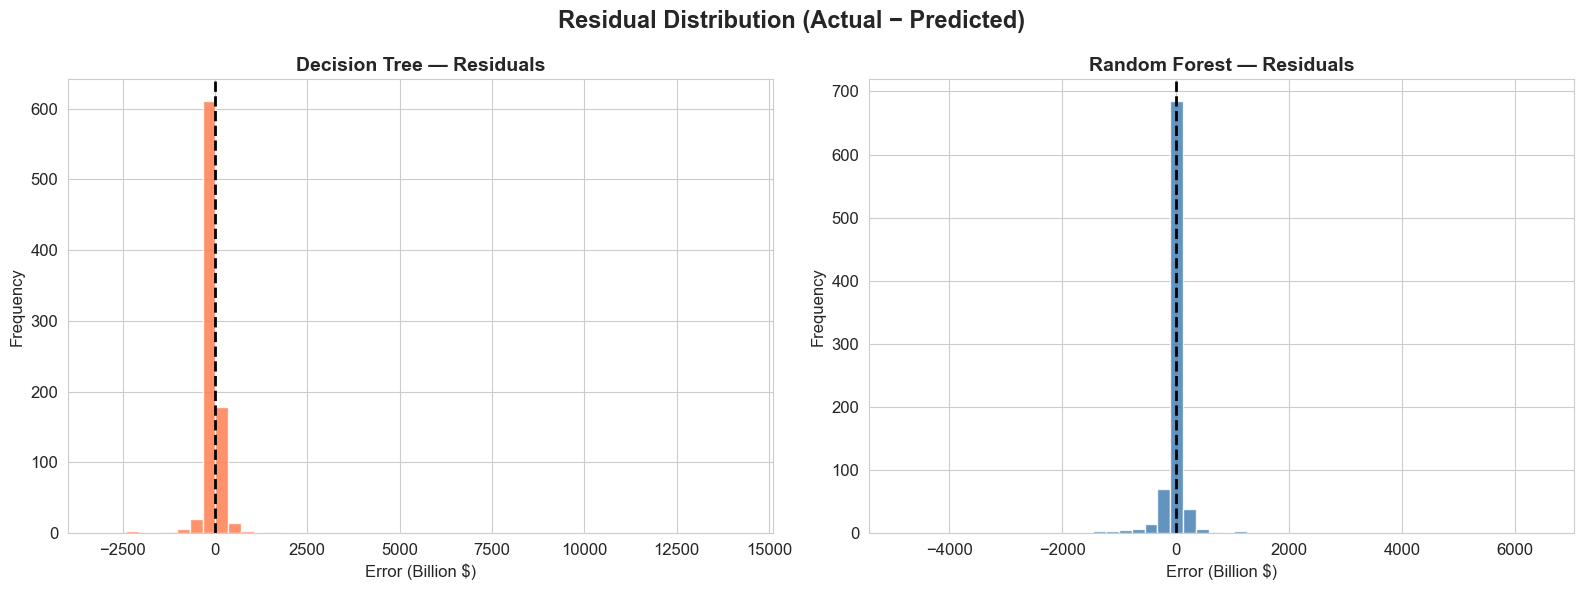

💡 Both distributions are centered near 0 = models are not systematically biased
   Decision Tree — Mean Error: $8.23B | Std: $598.71B
   Random Forest — Mean Error: $-21.11B | Std: $447.85B


In [49]:
residuals_dt = y_test - y_pred_dt
residuals_rf = y_test - y_pred_rf
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
axes[0].hist(residuals_dt / 1e9, bins=50, color='coral', edgecolor='white', alpha=0.85)
axes[0].axvline(0, color='black', linestyle='--', lw=2)
axes[0].set_title('Decision Tree — Residuals', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Error (Billion $)')
axes[0].set_ylabel('Frequency')
axes[1].hist(residuals_rf / 1e9, bins=50, color='steelblue', edgecolor='white', alpha=0.85)
axes[1].axvline(0, color='black', linestyle='--', lw=2)
axes[1].set_title('Random Forest — Residuals', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Error (Billion $)')
axes[1].set_ylabel('Frequency')
plt.suptitle('Residual Distribution (Actual − Predicted)', fontsize=17, fontweight='bold')
plt.tight_layout()
plt.show()
print("💡 Both distributions are centered near 0 = models are not systematically biased")
print(f"   Decision Tree — Mean Error: ${residuals_dt.mean()/1e9:.2f}B | Std: ${residuals_dt.std()/1e9:.2f}B")
print(f"   Random Forest — Mean Error: ${residuals_rf.mean()/1e9:.2f}B | Std: ${residuals_rf.std()/1e9:.2f}B")

# Final Project Summary

In [50]:
best_model = "Random Forest" if rf_r2 > dt_r2 else "Decision Tree"
best_r2 = max(rf_r2, dt_r2)
best_mae = rf_mae if rf_r2 > dt_r2 else dt_mae
best_rmse = rf_rmse if rf_r2 > dt_r2 else dt_rmse

print("=" * 65)
print(" FINAL PROJECT SUMMARY")
print("   GDP Prediction using BI & Machine Learning")
print("=" * 65)

print(f"""
 DATA SOURCE: World Bank — Global GDP & Macroeconomic Indicators

 DATASET OVERVIEW:
   • 7 Excel files integrated into 1 unified dataset
   • {df_clean['Country Name'].nunique()} countries | Years {df_clean['Year'].min()}–{df_clean['Year'].max()}
   • {len(df_clean)} total records after cleaning

 TARGET VARIABLE:
   • GDP (current US$)

 FEATURES USED (6):
   • Exports (% of GDP)
   • Imports (% of GDP)
   • FDI Inflows (% of GDP)
   • Inflation (annual %)
   • Population (total)
   • Govt Expenditure on Education (% of GDP)

 KEY EDA INSIGHTS:
   • Population is the strongest predictor of GDP (importance: 0.617)
   • Exports & Imports are highly correlated with each other (0.82)
   • Most features show weak direct linear correlation with GDP

 MODELS TRAINED:
   ┌─────────────────────┬──────────────┬──────────────┐
   │ Metric              │ Decision Tree│ Random Forest│
   ├─────────────────────┼──────────────┼──────────────┤
   │ MAE (Billion $)     │ {dt_mae/1e9:>12.2f}│ {rf_mae/1e9:>12.2f}│
   │ RMSE (Billion $)    │ {dt_rmse/1e9:>12.2f}│ {rf_rmse/1e9:>12.2f}│
   │ R² Score            │ {dt_r2:>12.4f}│ {rf_r2:>12.4f}│
   └─────────────────────┴──────────────┴──────────────┘

 BEST MODEL: {best_model}
   • R² Score: {best_r2:.4f} (explains {best_r2*100:.1f}% of GDP variance)
   • MAE: ${best_mae/1e9:.2f} Billion
   • RMSE: ${best_rmse/1e9:.2f} Billion

 CONCLUSION:
   Random Forest outperforms Decision Tree across all metrics.
   Population is the dominant factor in predicting GDP, followed by
   Imports and Government Expenditure on Education.
""")

 FINAL PROJECT SUMMARY
   GDP Prediction using BI & Machine Learning

 DATA SOURCE: World Bank — Global GDP & Macroeconomic Indicators

 DATASET OVERVIEW:
   • 7 Excel files integrated into 1 unified dataset
   • 171 countries | Years 2000–2024
   • 4237 total records after cleaning

 TARGET VARIABLE:
   • GDP (current US$)

 FEATURES USED (6):
   • Exports (% of GDP)
   • Imports (% of GDP)
   • FDI Inflows (% of GDP)
   • Inflation (annual %)
   • Population (total)
   • Govt Expenditure on Education (% of GDP)

 KEY EDA INSIGHTS:
   • Population is the strongest predictor of GDP (importance: 0.617)
   • Exports & Imports are highly correlated with each other (0.82)
   • Most features show weak direct linear correlation with GDP

 MODELS TRAINED:
   ┌─────────────────────┬──────────────┬──────────────┐
   │ Metric              │ Decision Tree│ Random Forest│
   ├─────────────────────┼──────────────┼──────────────┤
   │ MAE (Billion $)     │       123.12│       114.73│
   │ RMSE (Bill

# Export Data for Power BI

In [53]:
# 1. Main dataset — all countries, all years, all features
df_clean.to_csv('PowerBI_GDP_Main.csv', index=False)
print(f" Saved: PowerBI_GDP_Main.csv ({len(df_clean)} rows)")

 Saved: PowerBI_GDP_Main.csv (4237 rows)


In [54]:
# 2. Predictions — actual vs predicted GDP for both models
predictions_df = pd.DataFrame({
    'Country Name': df_clean.loc[y_test.index, 'Country Name'].values,
    'Year': df_clean.loc[y_test.index, 'Year'].values,
    'Actual_GDP': y_test.values,
    'DT_Predicted': y_pred_dt,
    'RF_Predicted': y_pred_rf,
    'DT_Error': y_test.values - y_pred_dt,
    'RF_Error': y_test.values - y_pred_rf
})
predictions_df.to_csv('PowerBI_Predictions.csv', index=False)
print(f" Saved: PowerBI_Predictions.csv ({len(predictions_df)} rows)")

 Saved: PowerBI_Predictions.csv (848 rows)


In [55]:
# 3. Feature importance
importance_df = pd.DataFrame({
    'Feature': feature_cols,
    'Importance': rf_model.feature_importances_
}).sort_values('Importance', ascending=False)
importance_df.to_csv('PowerBI_Feature_Importance.csv', index=False)
print(f" Saved: PowerBI_Feature_Importance.csv ({len(importance_df)} rows)")
print(f"\n All 3 files saved in: {os.getcwd()}")
print(" Now open Power BI Desktop → Get Data → Text/CSV → import these files")

 Saved: PowerBI_Feature_Importance.csv (6 rows)

 All 3 files saved in: C:\Users\DELL\data_science\BI Project On GDP
 Now open Power BI Desktop → Get Data → Text/CSV → import these files


In [58]:
# Export as Excel instead of CSV — Power BI reads types correctly from Excel
!pip install openpyxl

df_powerbi = df_clean.copy().fillna(0)
numeric_cols = ['GDP', 'Exports', 'Imports', 'FDI_Inflows', 'Inflation', 'Population', 'Govt_Expenditure']
for col in numeric_cols:
    df_powerbi[col] = pd.to_numeric(df_powerbi[col], errors='coerce').fillna(0)
df_powerbi['Year'] = df_powerbi['Year'].astype(int)

# Save as Excel
df_powerbi.to_excel('PowerBI_GDP_Main.xlsx', index=False)
print(f" Saved: PowerBI_GDP_Main.xlsx ({len(df_powerbi)} rows)")

# Predictions
predictions_df = pd.DataFrame({
    'Country Name': df_clean.loc[y_test.index, 'Country Name'].values,
    'Year': df_clean.loc[y_test.index, 'Year'].astype(int).values,
    'Actual_GDP': y_test.values.astype(float),
    'DT_Predicted': y_pred_dt.astype(float),
    'RF_Predicted': y_pred_rf.astype(float),
    'DT_Error': (y_test.values - y_pred_dt).astype(float),
    'RF_Error': (y_test.values - y_pred_rf).astype(float)
})
predictions_df.to_excel('PowerBI_Predictions.xlsx', index=False)
print(f" Saved: PowerBI_Predictions.xlsx")

# Feature importance
importance_df = pd.DataFrame({
    'Feature': feature_cols,
    'Importance': rf_model.feature_importances_.astype(float)
}).sort_values('Importance', ascending=False)
importance_df.to_excel('PowerBI_Feature_Importance.xlsx', index=False)
print(f" Saved: PowerBI_Feature_Importance.xlsx")

print("\n📌 Now import these .xlsx files into Power BI instead of the CSVs")

 Saved: PowerBI_GDP_Main.xlsx (4237 rows)
 Saved: PowerBI_Predictions.xlsx
 Saved: PowerBI_Feature_Importance.xlsx

📌 Now import these .xlsx files into Power BI instead of the CSVs
